In [1]:
import sys
sys.path.append("../")

import os
os.environ["XLA_FLAGS"] = "--xla_gpu_force_compilation_parallelism=1"

%reload_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist

import numpy as np
import arviz as az
import mpltern
import corner
import pickle
import logging
from tqdm import tqdm

In [3]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
#mpl.rc_file('../notebooks/matplotlibrc')
import mpltern

In [4]:
jax.devices()

[StreamExecutorGpuDevice(id=0, process_index=0, slice_index=0)]

In [5]:
data_dir = '../data/posteriors/fit_process'

In [6]:
from models.np_model import NPModel

In [7]:
default_expand_keys = {
    'theta_bulge_poiss' : ['theta_p_mcdermott2022', 'theta_p_mcdermott2022_bbp', 'theta_p_mcdermott2022_x',
                           'theta_p_macias2019', 'theta_p_coleman2019'],
    'theta_bulge_ps' : ['theta_ps_mcdermott2022', 'theta_ps_mcdermott2022_bbp', 'theta_ps_mcdermott2022_x',
                        'theta_ps_macias2019', 'theta_ps_coleman2019'],
    'theta_ics'    : ['theta_MO_ics', 'theta_MA_ics', 'theta_MF_ics'],
    'theta_pibrem' : ['theta_MO_pib', 'theta_MA_pib', 'theta_MF_pib'],
}

#default_exclude_keys = ['auto_shared_latent']
default_exclude_keys = []

def expand_samples(samples, expand_keys=default_expand_keys, exclude_keys=default_exclude_keys, conversion_func=(lambda x: x)):
    
    samples_new = {}
    for k in samples.keys():
        if k in exclude_keys:
            continue
        if k in expand_keys:
            for i in range(samples[k].shape[-1]):
                samples_new[expand_keys[k][i]] = conversion_func(samples[k][...,i])
        else:
            samples_new[k] = conversion_func(samples[k])
            
    return samples_new

## 1. Training process gif

In [16]:
npmodel = NPModel(
    non_poissonian=False,
    l_max=1,
    vary_gamma=True,
    bulge_hybrid=True,
    ps_cat="3fgl",
    nside=128,
)

In [13]:
svi_results = npmodel.fit_svi(
    rng_key=jax.random.PRNGKey(42),
    n_steps=7500,
    guide="iaf_mixture",
    num_base_mixture=4,
    lr=5e-5,
    num_flows=4,
    hidden_dims=[128, 128],
    num_particles=8,
)

100%|████████████████| 7500/7500 [01:01<00:00, 122.70it/s, init loss: 39080.0943, avg. loss [7126-7500]: 20206.6908]


[]

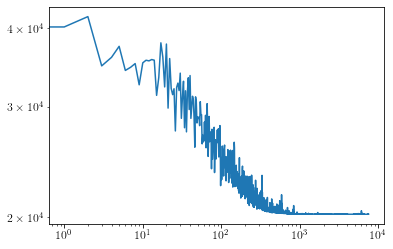

In [14]:
plt.plot(svi_results.losses)
plt.loglog()

In [15]:
n_steps_arr = np.linspace(10, 2000, 50, dtype=np.int32)
print(n_steps_arr)

[  10   50   91  131  172  213  253  294  334  375  416  456  497  537
  578  619  659  700  741  781  822  862  903  944  984 1025 1065 1106
 1147 1187 1228 1268 1309 1350 1390 1431 1472 1512 1553 1593 1634 1675
 1715 1756 1796 1837 1878 1918 1959 2000]


In [ ]:
for i, n_steps in enumerate(n_steps_arr):
    n_steps = int(n_steps)
    print(f'{i+1}/{len(n_steps_arr)} n_steps = {n_steps} :')
    svi_results = npmodel.fit_svi(
        rng_key=jax.random.PRNGKey(42),
        n_steps=n_steps,
        guide="iaf",
        num_base_mixture=4,
        lr=5e-5,
        num_flows=4,
        hidden_dims=[128, 128],
        num_particles=8,
        reinit=False,
    )
    posterior = npmodel.get_posterior_samples(
        rng_key=jax.random.PRNGKey(42),
        num_samples=50000,
    )
    pickle.dump((expand_samples(posterior), svi_results), open(f'../data/posteriors/fit_process/n_steps_{n_steps}.p', 'wb'))

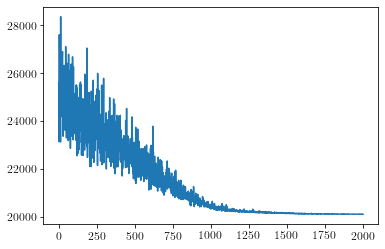

In [23]:
plt.plot(svi_results.losses)

In [41]:
samples_arr = []
for i, n_steps in enumerate(n_steps_arr):
    samples_arr.append(pickle.load(open(f'../data/posteriors/fit_process/n_steps_{n_steps}.p', 'rb')))

plot_var_names = [
    #'S_bub', 'S_dif', 'S_gce', 'S_ics', 'S_iso',
    'f_bulge_poiss', 'gamma_poiss',
    'f_bulge_ps', 'gamma_ps',
    'C', 'zs',
    'theta_ps_macias2019', 'theta_ps_coleman2019'
]

samples = samples_arr[-1]

n_bins_1d = 30
bins_1d_arr = []
range_arr = []
for vn in plot_var_names:
    vmin = np.min(samples[vn])
    vmax = np.max(samples[vn])
    bins_1d_arr.append(np.linspace(vmin, vmax, n_bins_1d + 1))
    range_arr.append([vmin, vmax])

for i, samples in enumerate(tqdm(samples_arr)):
    figure = None
    figure = corner.corner(
        samples,
        range=range_arr,
        bins_1d_arr=bins_1d_arr,
        var_names=plot_var_names,
        show_titles=True,
        title_kwargs={"fontsize": 14},
        levels = [0.68, 0.95],
        color = 'firebrick',
        plot_contours=True,
        fill_contours=True,
        plot_density=False,
        plot_datapoints=False,
    )
    figure.text(0.2, 0.9, f'step = {n_steps_arr[i]}', fontsize=20, color='firebrick')
    plt.savefig(f'../data/posteriors/fit_process/plots/{i}.png')
    plt.close()

100%|███████████████████████████████████████████████████████████████████████████████| 20/20 [02:21<00:00,  7.05s/it]


In [43]:
import glob
import contextlib
from PIL import Image
import os
import numpy as np

# filepaths
fp_in = "../data/posteriors/fit_process/plots/*.png"
fp_out = "../data/posteriors/fit_process/process.gif"

# use exit stack to automatically close opened images
flist = glob.glob(fp_in)
with contextlib.ExitStack() as stack:
    imgs = (stack.enter_context(Image.open(f))
            for f in sorted(flist, key=lambda x: int(os.path.basename(x).split('.')[0])))

    # Add a white background to each frame
    imgs_with_background = []
    for img in imgs:
        img_with_bg = Image.new('RGBA', img.size, (255, 255, 255))
        img_with_bg.paste(img, (0, 0), img)
        imgs_with_background.append(img_with_bg.convert('RGB'))

    # extract first image from list
    durations = np.full(len(imgs_with_background), 500)
    durations[-1] = 2000
    img = imgs_with_background[0]

    # https://pillow.readthedocs.io/en/stable/handbook/image-file-formats.html#gif
    img.save(fp=fp_out, format='GIF', append_images=imgs_with_background[1:],
             save_all=True, duration=list(durations), loop=0)

## 5. Plot all variables

In [28]:
samples.keys()

dict_keys(['Alm_0', 'Alm_1', 'C', 'S_bub', 'S_dif', 'S_gce', 'S_ics', 'S_iso', 'S_psc', 'Sps_dsk', 'Sps_gce', 'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'lambdas_dsk', 'lambdas_gce', 'n1_dsk', 'n1_gce', 'n2_dsk', 'n2_gce', 'n3_dsk', 'n3_gce', 'sb1_dsk', 'sb1_gce', 'theta_p_mcdermott2022', 'theta_p_mcdermott2022_bbp', 'theta_p_mcdermott2022_x', 'theta_p_macias2019', 'theta_p_coleman2019', 'theta_ps_mcdermott2022', 'theta_ps_mcdermott2022_bbp', 'theta_ps_mcdermott2022_x', 'theta_ps_macias2019', 'theta_ps_coleman2019', 'theta_MO_ics', 'theta_MA_ics', 'theta_MF_ics', 'theta_MO_pib', 'theta_MA_pib', 'theta_MF_pib', 'zs'])

In [ ]:
plot_var_names = list(samples.keys())

n_bins_1d = 30
bins_1d_arr = []
for vn in plot_var_names:
    vmin = np.min(samples[vn])
    vmax = np.max(samples[vn])
    bins_1d_arr.append(np.linspace(vmin, vmax, n_bins_1d + 1))

figure = corner.corner(
    samples,
    bins_1d_arr=bins_1d_arr,
    var_names=plot_var_names,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    levels = [0.68, 0.95],
    color = 'firebrick',
    plot_contours=True,
    fill_contours=True,
    plot_density=False,
    plot_datapoints=False,
)